# Network Intrusion Classification – Dummy Test Pipeline

Lightweight test pipeline using a **100_000-row stratified sample** of the CICIDS2017 dataset.

**Steps:**
1. Load data & stratified sampling
2. Pre-processing (scaling, label encoding)
3. Feature selection (SelectKBest – ANOVA F-score)
4. Dimensionality reduction (PCA)
5. Model training with GridSearchCV (rough param grids)
6. Evaluation & comparison

## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000

## 2 · Load Data & Stratified Sampling

In [2]:
# Load dataset
try:
    df = pd.read_csv("data/cicids2017_cleaned.csv")
    print(f"Dataset loaded – shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Loading failed: {e}")

X_full = df.iloc[:, :-1]
y_full = df.iloc[:, -1]

print("\nClass distribution (full dataset):")
print(y_full.value_counts())

Dataset loaded – shape: (2520751, 53)

Class distribution (full dataset):
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [3]:
# Stratified sample of 500 rows
sss = StratifiedShuffleSplit(n_splits=1, train_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
sample_idx, _ = next(sss.split(X_full, y_full))

X_sample = X_full.iloc[sample_idx].reset_index(drop=True)
y_sample = y_full.iloc[sample_idx].reset_index(drop=True)

print(f"Sampled rows : {len(X_sample)}")
print(f"Feature count: {X_sample.shape[1]}")
print("\nClass distribution (sample):")
print(y_sample.value_counts())

Sampled rows : 100000
Feature count: 52

Class distribution (sample):
Attack Type
Normal Traffic    83113
DoS                7686
DDoS               5078
Port Scanning      3598
Brute Force         363
Web Attacks          85
Bots                 77
Name: count, dtype: int64


## 3 · Pre-processing

In [4]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_sample)
print("Classes:", list(le.classes_))

# Remove inf/NaN, drop zero-variance columns, impute medians
X_clean = X_sample.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.dropna(axis=1, how='all')
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))
X_clean = X_clean.loc[:, X_clean.std() > 0]
print(f"Features after cleaning: {X_clean.shape[1]}")

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean.values, y_encoded,
    test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Classes: ['Bots', 'Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scanning', 'Web Attacks']
Features after cleaning: 52
Train: (80000, 52)  |  Test: (20000, 52)


## 4 · Feature Selection (SelectKBest, top 20)

Selected 20 features:
  • Flow Duration
  • Bwd Packet Length Max
  • Bwd Packet Length Mean
  • Bwd Packet Length Std
  • Flow IAT Mean
  • Flow IAT Std
  • Flow IAT Max
  • Fwd IAT Total
  • Fwd IAT Std
  • Fwd IAT Max
  • Bwd IAT Std
  • Max Packet Length
  • Packet Length Mean
  • Packet Length Std
  • Packet Length Variance
  • FIN Flag Count
  • Average Packet Size
  • Idle Mean
  • Idle Max
  • Idle Min


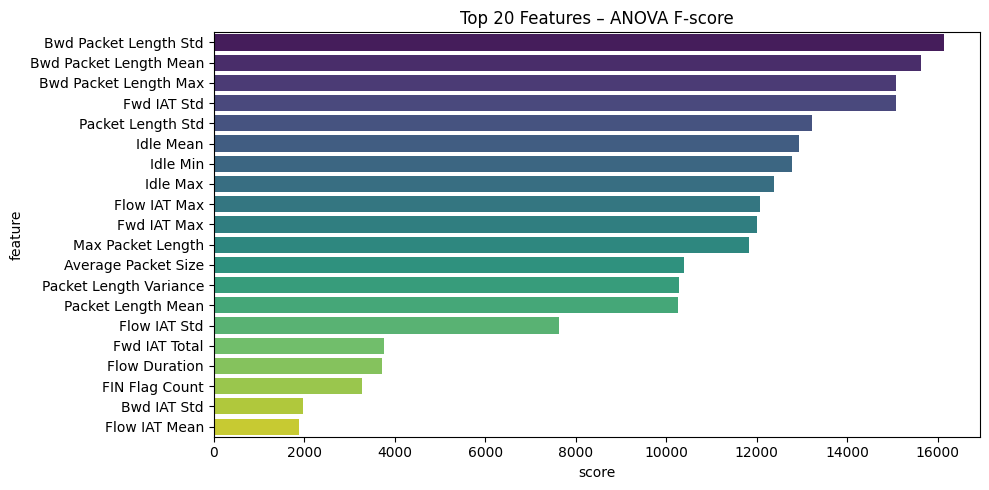

In [5]:
K_FEATURES = 20

# Scale, then select top-K features by ANOVA F-score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs  = selector.transform(X_test_scaled)

selected_names = X_clean.columns[selector.get_support()].tolist()
print(f"Selected {K_FEATURES} features:")
for f in selected_names:
    print(f"  • {f}")

# Bar chart of feature scores
scores_df = pd.DataFrame({'feature': X_clean.columns, 'score': selector.scores_}) \
              .sort_values('score', ascending=False).head(K_FEATURES)

plt.figure(figsize=(10, 5))
sns.barplot(data=scores_df, x='score', y='feature', palette='viridis')
plt.title(f'Top {K_FEATURES} Features – ANOVA F-score')
plt.tight_layout()
plt.show()

## 5 · Dimensionality Reduction (PCA, 10 components)

Cumulative variance (10 components): 99.4%


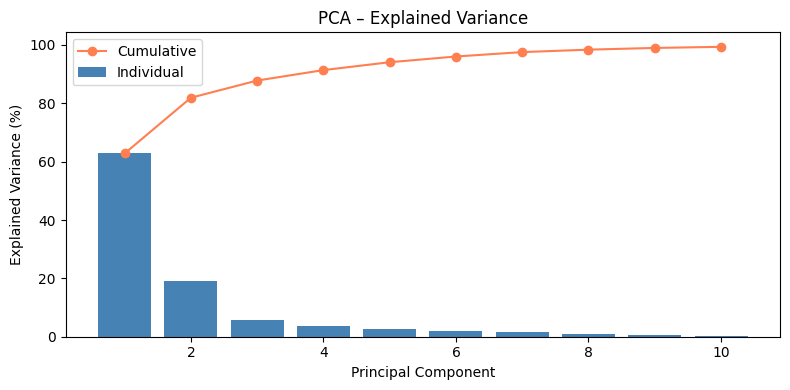

In [6]:
N_COMPONENTS = 10

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_fs)
X_test_pca  = pca.transform(X_test_fs)

cumulative = np.cumsum(pca.explained_variance_ratio_)
print(f"Cumulative variance ({N_COMPONENTS} components): {cumulative[-1]*100:.1f}%")

# Scree plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, N_COMPONENTS + 1), pca.explained_variance_ratio_ * 100,
        label='Individual', color='steelblue')
plt.plot(range(1, N_COMPONENTS + 1), cumulative * 100,
         marker='o', color='coral', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA – Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

## 6 · SMOTE

In [7]:
sm = SMOTE(sampling_strategy="auto", random_state=RANDOM_STATE, k_neighbors=3)

# SMOTE, no PCA
X_train_sm, y_train_sm = sm.fit_resample(X_train_fs, y_train)

# SMOTE and PCA
X_train_pca_sm, y_train_sm = sm.fit_resample(X_train_pca, y_train)

## 7 · Model Training with GridSearchCV

Each classifier is tuned with a **rough parameter grid** (5-fold CV) on the
feature-selected input. The best estimator is then also scored on the PCA input.

In [8]:
# Rough parameter grids
models = {
    'SVM': {
        'pipeline': Pipeline([('clf', SVC())]),
        'params': {'clf__C': [0.1, 1, 10],
                   'clf__degree': [2, 3],
                   'clf__decision_function_shape': ['ovo']
                   }
    },
    'LogisticRegression': {
        'pipeline': Pipeline([('clf', LogisticRegression(max_iter=10000, 
                                                         random_state=RANDOM_STATE, 
                                                         solver='lbfgs'))]),
        'params': {'clf__C': [0.1, 1, 10]}
    },
    'k-NN': {
        'pipeline': Pipeline([('clf', KNeighborsClassifier())]),
        'params': {'clf__n_neighbors': [3], 
                   'clf__leaf_size': [1],
                   'clf__weights': ['distance'], 
                   'clf__metric': ['manhattan'],
                   'clf__p': [1]
                   }
    },
    'Naive Bayes': {
        'pipeline': Pipeline([('clf', GaussianNB())]),
        'params': {'clf__var_smoothing': [1e-5]}
    },
    'RandomForest': {
        'pipeline': Pipeline([('clf', RandomForestClassifier(random_state=RANDOM_STATE))]),
        'params': {'clf__n_estimators': [149, 150, 152], 
                   'clf__max_depth': [15],
                   'clf__criterion': ["entropy"],
                   'clf__min_samples_leaf': [1],
                   'clf__min_samples_split': [3]
                   }
    },
}

results = {}

for name, config in models.items():
    print(f"Training {name}...")
    # Grid search on FS input
    gs = GridSearchCV(config['pipeline'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train_fs, y_train)
    best = gs.best_estimator_

    # Score on FS test set
    y_pred_fs = best.predict(X_test_fs)

    # Re-fit best params on PCA input, then score
    pca_model = copy.deepcopy(best)
    pca_model.fit(X_train_pca, y_train)
    y_pred_pca = pca_model.predict(X_test_pca)

    results[name] = {
        'best_params': gs.best_params_,
        'cv_score'   : gs.best_score_,
        'acc_fs'     : accuracy_score(y_test, y_pred_fs),
        'acc_pca'    : accuracy_score(y_test, y_pred_pca) if y_pred_pca is not None else np.nan,
        'f1_fs'      : f1_score(y_test, y_pred_fs, average='macro'),
        'f1_pca'     : f1_score(y_test, y_pred_pca, average='macro') if y_pred_pca is not None else np.nan,
        'y_pred_fs'  : y_pred_fs,
        'report_fs'  : classification_report(y_test, y_pred_fs,
                           labels=np.unique(y_test),
                           target_names=le.inverse_transform(np.unique(y_test)),
                           zero_division=0),
        'report_pca' : classification_report(y_test, y_pred_pca,
                           labels=np.unique(y_test),
                           target_names=le.inverse_transform(np.unique(y_test)),
                           zero_division=0) if y_pred_pca is not None else "N/A",
    }
    print(f"{name:22s}  best={gs.best_params_}  CV={gs.best_score_:.4f}")

print("\nGrid search complete.")

Training SVM...


SVM                     best={'clf__C': 10, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2}  CV=0.9405
Training LogisticRegression...
LogisticRegression      best={'clf__C': 10}  CV=0.9177
Training k-NN...
k-NN                    best={'clf__leaf_size': 1, 'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}  CV=0.9938
Training Naive Bayes...
Naive Bayes             best={'clf__var_smoothing': 1e-05}  CV=0.2210
Training RandomForest...
RandomForest            best={'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 3, 'clf__n_estimators': 152}  CV=0.9954

Grid search complete.


## 8 · Evaluation & Comparison

In [9]:
# Summary table
rows = []
for name, r in results.items():
    rows.append({'Model': name, 'Best Params': r['best_params'],
                 'CV Acc': round(r['cv_score'], 4),
                 'Test Acc (FS)': round(r['acc_fs'], 4),
                'Test Acc (PCA)': round(r['acc_pca'], 4)}),

summary = pd.DataFrame(rows)
print("=" * 75)
print("MODEL COMPARISON SUMMARY")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)

MODEL COMPARISON SUMMARY
             Model                                                                                                                            Best Params  CV Acc  Test Acc (FS)  Test Acc (PCA)
               SVM                                                                {'clf__C': 10, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2}  0.9406         0.9420          0.9375
LogisticRegression                                                                                                                         {'clf__C': 10}  0.9177         0.9197          0.9126
              k-NN                      {'clf__leaf_size': 1, 'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}  0.9938         0.9942          0.9939
       Naive Bayes                                                                                                          {'clf__var_smoothing': 1e-05}  0.2210         0.2086          0.2897
      Rand

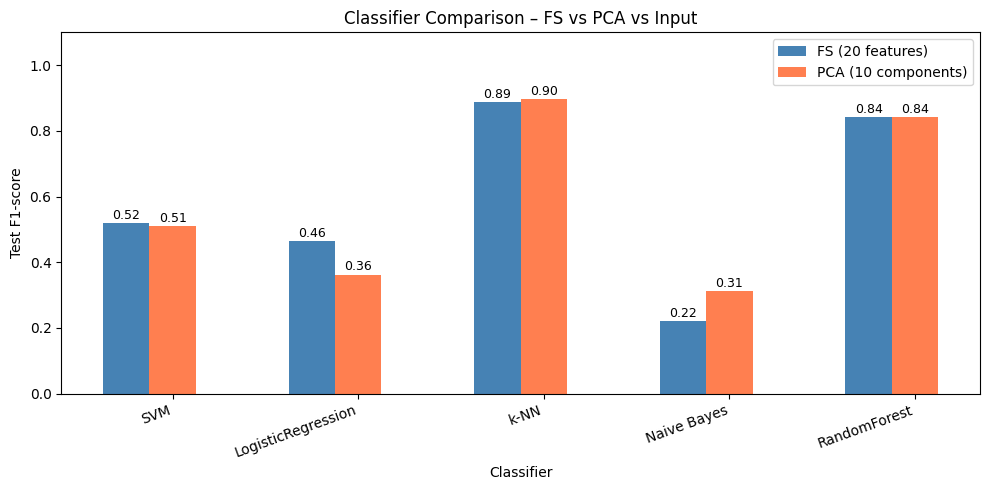

In [10]:
# Bar chart – FS vs PCA vs SMOTE test F1-score per classifier
labels = list(results.keys())

def _as_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan

f1_fs = np.array([_as_float(results[n].get('f1_fs', np.nan)) for n in labels], dtype=float)
f1_pca = np.array([_as_float(results[n].get('f1_pca', np.nan)) for n in labels], dtype=float)

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, f1_fs, width, label='FS (20 features)', color='steelblue')
bars2 = ax.bar(x,         f1_pca, width, label='PCA (10 components)', color='coral')

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        if np.isfinite(h):
            ax.annotate(
                f'{h:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                fontsize=9
            )

ax.set_xlabel('Classifier')
ax.set_ylabel('Test F1-score')
ax.set_title('Classifier Comparison – FS vs PCA vs Input')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

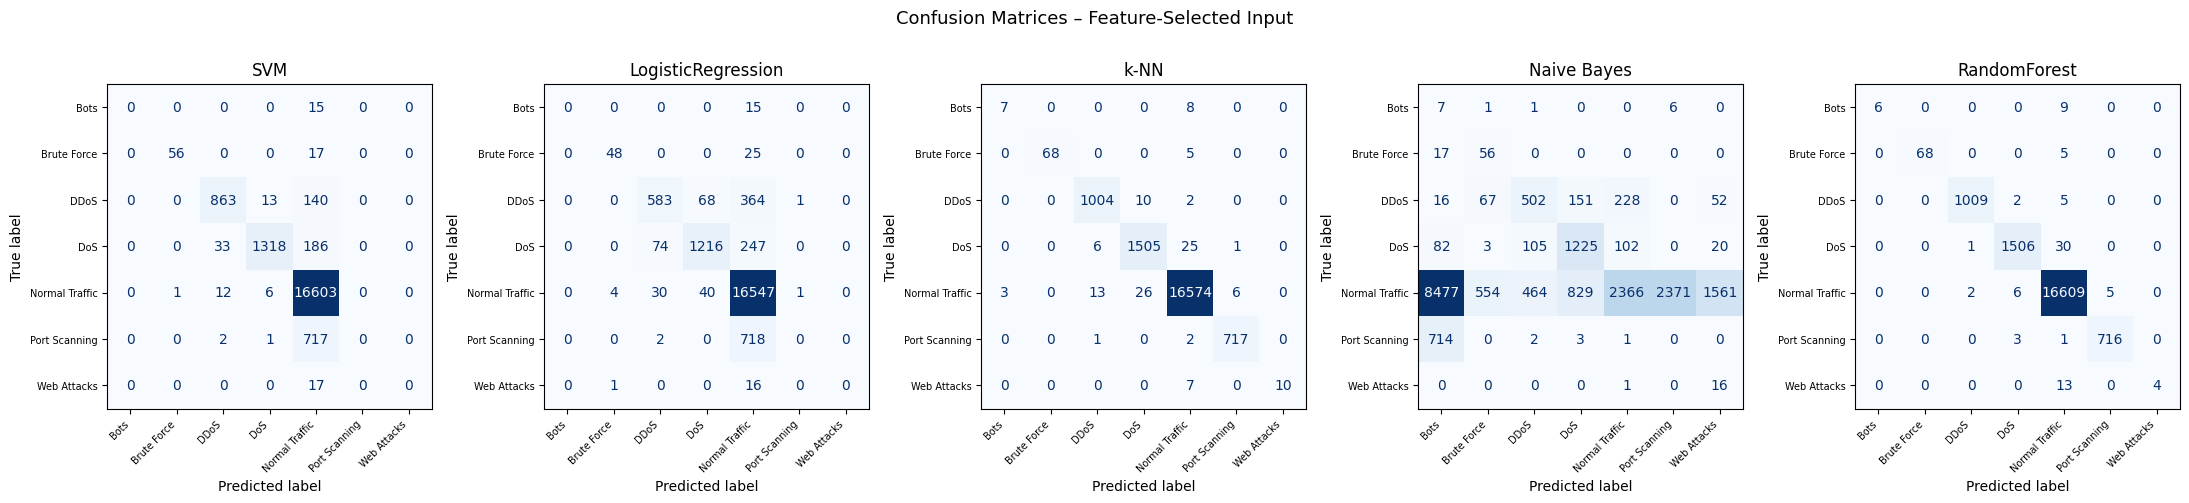

In [26]:
# Confusion matrices (FS input)

fig, axes = plt.subplots(1,5, figsize=(22, 5))
fig.suptitle('Confusion Matrices – Feature-Selected Input', fontsize=13)
for ax, name in zip(axes, results):
    cm = confusion_matrix(y_test, results[name]['y_pred_fs'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.inverse_transform(np.unique(y_test)))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

plt.tight_layout()
plt.show()



In [27]:
# Per-class classification reports
for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"  {name}  –  FS input  (best params: {r['best_params']})")
    print('='*60)
    print(r['report_fs'])

    print(f"\n{'='*60}")
    print(f"  {name}  –  PCA input")
    print('='*60)
    print(r['report_pca'])


  SVM  –  FS input  (best params: {'clf__C': 10, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2})
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        15
   Brute Force       0.98      0.77      0.86        73
          DDoS       0.95      0.85      0.90      1016
           DoS       0.99      0.86      0.92      1537
Normal Traffic       0.94      1.00      0.97     16622
 Port Scanning       0.00      0.00      0.00       720
   Web Attacks       0.00      0.00      0.00        17

      accuracy                           0.94     20000
     macro avg       0.55      0.50      0.52     20000
  weighted avg       0.91      0.94      0.92     20000


  SVM  –  PCA input
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        15
   Brute Force       0.98      0.77      0.86        73
          DDoS       0.88      0.83      0.85      1016
           DoS       0.97  